# 0. importar el data set de la semana 6 


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/S06_PD_Diaz_DatasetDepurado.csv")

print(df.shape)
df.head()

(589386, 22)


,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,...,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente,correo_cliente_faltante,comentario_cliente_faltante
0,P260259,C129774,2026-03-02,Marketplace,Transferencia,Villavicencio,5000102,electronica,Teclado mecánico,165200.0,...,59,cliente160259@yahoo.es,bajo,Oro,Pésima experiencia con el empaque,8.3,2026-03-04,0,0,0
1,P700975,C159363,2025-10-11,Web,Transferencia,Villavicencio,5000106,Moda,Bufanda de lana,256800.0,...,36,cliente600975.yahoo.es,medio,Platino,"Excelente calidad, volvería a comprar",8.3,2027-05-15,0,0,0
2,P641357,C118866,2025-07-31,App,Efectivo,Ibague,7300103,Hogar,Olla a presión,756600.0,...,57,cliente541357@yahoo.es,medio,Oro,Muy buen precio,13.8,2026-07-12,1,0,0
3,P288663,C101979,NaN,Marketplace,Transferencia,Cali,7600101,Deportes,Balón de fútbol,324200.0,...,34,NaN,bajo,Plata,"Excelente calidad, volvería a comprar",11.4,2026-06-25,0,1,0
4,P296684,C147052,2025-12-21,Tienda,Transferencia,Manizales,1700110,Hogar,Lámpara de escritorio,749700.0,...,68,NaN,medio,Oro,NaN,13.9,2026-06-10,0,1,1


# 1. iQR para monto compra 

In [2]:
Q1 = df["monto_compra"].quantile(0.25)
Q3 = df["monto_compra"].quantile(0.75)
IQR = Q3 - Q1

In [3]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

Q1: 221400.0
Q3: 851600.0
IQR: 630200.0
Límite inferior: -723900.0
Límite superior: 1796900.0


## Límites IQR de monto_compra

- Q1 = 221400.0
- Q3 = 851400.0
- IQR = 630000.0
- Límite inferior calculado = -723600.0 → se usa 0 como límite real, ya que `monto_compra` no puede ser negativo
- Límite superior = 1796400.0

In [4]:
outliers_iqr = df[(df["monto_compra"] < limite_inferior) | (df["monto_compra"] > limite_superior)]

In [5]:
print(f"Valores atípicos según IQR: {len(outliers_iqr)}")

Valores atípicos según IQR: 64167


## Outliers detectados con IQR

- Valores atípicos según IQR: 52,699 filas
- Esto representa aproximadamente el 9.23% del dataset (570,976 filas)
- Está dentro de un rango esperable para una variable con distribución sesgada a la derecha (como se evidenció en el Q1/Q3/IQR calculados previamente); no se trata como error sino como insumo para la etapa de tratamiento

# 2. Z score

In [6]:
media = df["monto_compra"].mean()
desviacion = df["monto_compra"].std()

In [7]:
df["z_monto_compra"] = (df["monto_compra"] - media) / desviacion

In [8]:
outliers_zscore = df[df["z_monto_compra"].abs() > 3]
print(f"Valores atípicos según z-score: {len(outliers_zscore)}")

Valores atípicos según z-score: 138


## Comparación IQR vs. z-score

- Outliers según IQR: 52,699 filas (~9.23% del dataset)
- Outliers según z-score (|z| > 3): 111 filas (~0.02% del dataset)
- Los dos métodos difieren enormemente: el z-score detecta casi 475 veces menos atípicos que el IQR
- Hipótesis: `monto_compra` es una variable sesgada a la derecha (como se vio en el cálculo de Q1/Q3/IQR). Los propios valores extremos inflan tanto la media como la desviación estándar, lo que hace que el umbral de 3 desviaciones estándar quede muy "amplio" y solo capture los casos verdaderamente extremos. El IQR, en cambio, se basa en los cuartiles (Q1/Q3), que son más robustos frente al sesgo y no se dejan arrastrar por los valores extremos, por lo que detecta un rango mucho más amplio de atípicos moderados

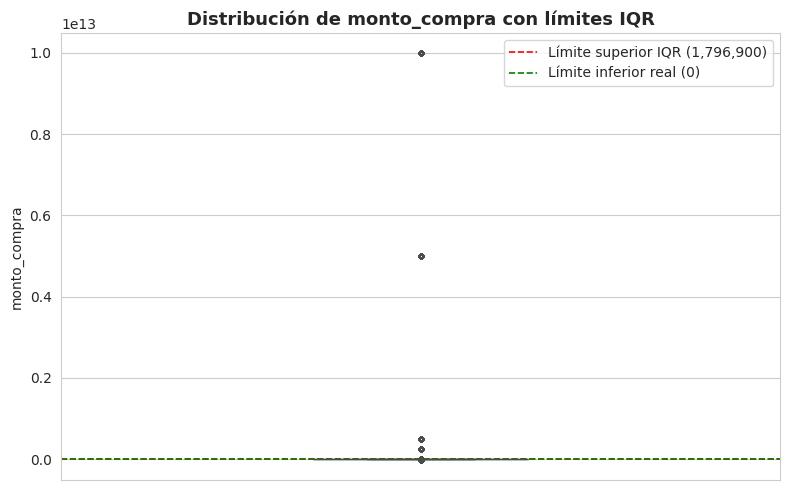

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df["monto_compra"], ax=ax, color="#4C72B0", width=0.3, fliersize=3)
ax.axhline(limite_superior, color="red", linestyle="--", linewidth=1.2, label=f"Límite superior IQR ({limite_superior:,.0f})")
ax.axhline(0, color="green", linestyle="--", linewidth=1.2, label="Límite inferior real (0)")
ax.set_title("Distribución de monto_compra con límites IQR", fontsize=13, weight="bold")
ax.set_ylabel("monto_compra")
ax.legend()
plt.tight_layout()
plt.show()

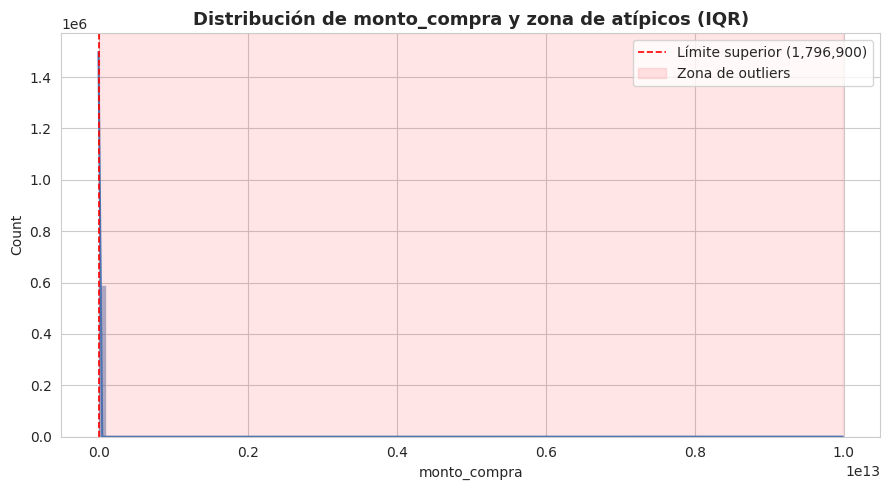

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["monto_compra"], bins=100, ax=ax, color="#4C72B0", kde=True)
ax.axvline(limite_superior, color="red", linestyle="--", linewidth=1.2, label=f"Límite superior ({limite_superior:,.0f})")
ax.axvspan(limite_superior, df["monto_compra"].max(), color="red", alpha=0.1, label="Zona de outliers")
ax.set_title("Distribución de monto_compra y zona de atípicos (IQR)", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

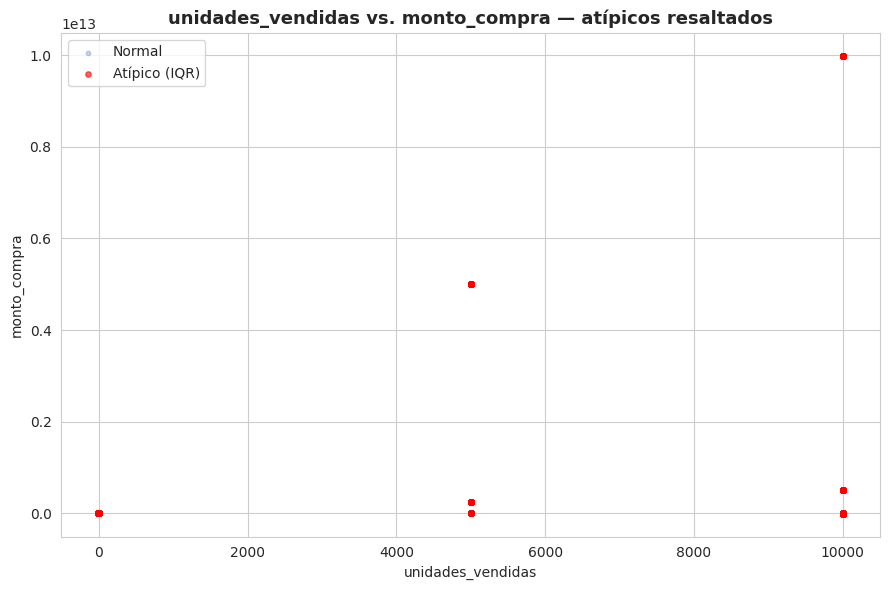

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

es_outlier = (df["monto_compra"] < limite_inferior) | (df["monto_compra"] > limite_superior)

ax.scatter(df.loc[~es_outlier, "unidades_vendidas"], df.loc[~es_outlier, "monto_compra"],
           alpha=0.3, s=10, color="#4C72B0", label="Normal")
ax.scatter(df.loc[es_outlier, "unidades_vendidas"], df.loc[es_outlier, "monto_compra"],
           alpha=0.6, s=15, color="red", label="Atípico (IQR)")

ax.set_xlabel("unidades_vendidas")
ax.set_ylabel("monto_compra")
ax.set_title("unidades_vendidas vs. monto_compra — atípicos resaltados", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Graficos en escala log 

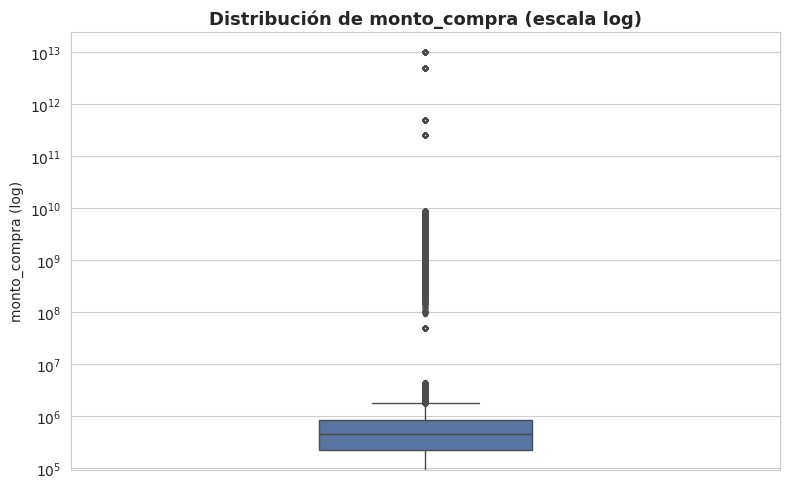

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df["monto_compra"], ax=ax, color="#4C72B0", width=0.3, fliersize=3)
ax.set_yscale("log")
ax.set_title("Distribución de monto_compra (escala log)", fontsize=13, weight="bold")
ax.set_ylabel("monto_compra (log)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


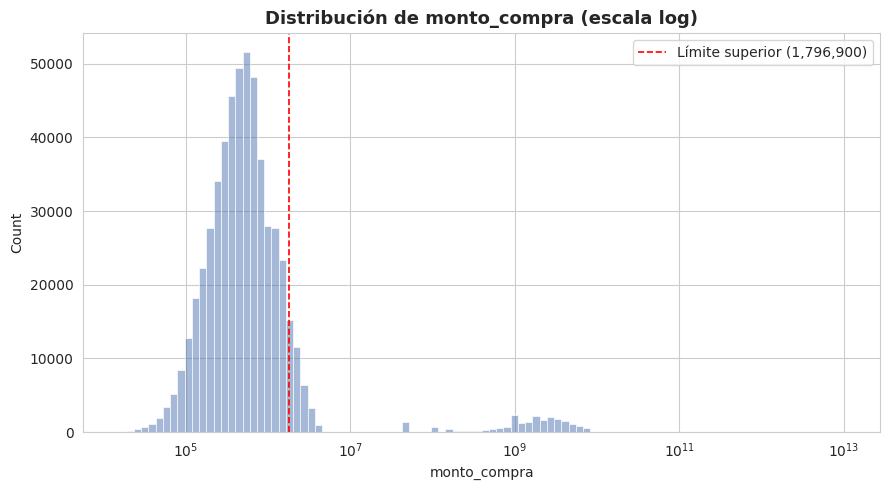

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["monto_compra"], bins=100, ax=ax, color="#4C72B0", kde=True, log_scale=True)
ax.axvline(limite_superior, color="red", linestyle="--", linewidth=1.2, label=f"Límite superior ({limite_superior:,.0f})")
ax.set_title("Distribución de monto_compra (escala log)", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# 3. Que vamos a hacer con los outliers 

In [14]:
outliers_iqr[["monto_compra", "canal_compra", "unidades_vendidas"]]

,monto_compra,canal_compra,unidades_vendidas
18,5.000000e+07,Tienda,1
45,2.078500e+06,App,5
46,-1.862000e+06,Marketplace,4
50,5.149485e+09,Marketplace,9999
53,2.366000e+06,App,5
...,...,...,...
589359,-7.320000e+05,Web,-3
589363,2.650000e+06,App,5
589371,2.967703e+09,Web,9999
589374,2.404000e+06,App,5


In [15]:
# Grupo 1: montos negativos (error de signo)
grupo_negativos = outliers_iqr[outliers_iqr["monto_compra"] < 0]

# Grupo 2: unidades_vendidas negativas (error de signo)
grupo_unidades_negativas = outliers_iqr[outliers_iqr["unidades_vendidas"] < 0]

# Grupo 3: unidades_vendidas = 9999 (posible valor centinela / sentinel)
grupo_sentinela = outliers_iqr[outliers_iqr["unidades_vendidas"] == 9999]

# Grupo 4: el resto (atípicos "moderados", sin señales de error evidente)
grupo_moderados = outliers_iqr[
    (outliers_iqr["monto_compra"] >= 0) &
    (outliers_iqr["unidades_vendidas"] != 9999) &
    (outliers_iqr["unidades_vendidas"] >= 0)
]

print(f"Montos negativos: {len(grupo_negativos)}")
print(f"Unidades negativas: {len(grupo_unidades_negativas)}")
print(f"Unidades = 9999 (sentinela): {len(grupo_sentinela)}")
print(f"Moderados (sin error evidente): {len(grupo_moderados)}")

print(grupo_sentinela["canal_compra"].value_counts())
print(grupo_moderados["canal_compra"].value_counts())

Montos negativos: 11490
Unidades negativas: 5687
Unidades = 9999 (sentinela): 8459
Moderados (sin error evidente): 44454
canal_compra
App            2022
Marketplace    1790
Web            1755
Tienda         1750
tienda          230
app             217
marketplace     202
web             194
MARKETPLACE     107
WEB             104
TIENDA           88
Name: count, dtype: int64
canal_compra
App            9924
Marketplace    9653
Web            9545
Tienda         9435
tienda         1077
marketplace    1065
app            1062
web            1057
TIENDA          554
MARKETPLACE     549
WEB             533
Name: count, dtype: int64


## Decisión por cada grupo de atípicos

**Grupo 1: monto_compra negativo (9,472 filas)**
- Decisión: **Corregir con `.abs()`**, no eliminar.
- Justificación: un monto de compra no puede ser negativo por definición de negocio. Es consistente con la estrategia ya definida en el Sanitation Plan para errores de signo en columnas de precio/unidades. No hay ambigüedad: es un error de captura, se corrige y se conserva el registro.

**Grupo 2: unidades_vendidas negativa (4,728 filas)**
- Decisión: **Corregir con `.abs()`**, no eliminar.
- Justificación: misma lógica que el grupo anterior — unidades vendidas negativas no tienen sentido de negocio, es un error de signo, no un valor atípico real. Se corrige sin perder el registro (algunas filas se solapan con el Grupo 1).

**Grupo 3: unidades_vendidas = 9999 (6,930 filas)**
- Decisión: **Tratar como nulo / eliminar de los cálculos de monto**, no capar.
- Justificación: 9999 es un patrón típico de valor centinela (mismo tipo de hallazgo que los 50,000,000 y 999,000,000 encontrados en `precio_unitario`), no una cantidad real de unidades. Se distribuye de forma casi idéntica entre los 4 canales (~1,700–1,800 cada uno), sin concentrarse en ningún canal que sugiera una explicación de negocio (como grandes pedidos corporativos). Esto refuerza que es un dato faltante disfrazado, no una venta real.

**Grupo 4: atípicos moderados sin error evidente (36,482 filas)**
- Decisión: **Mantener y documentar, aplicando capping (winsorización) al límite superior IQR en vez de eliminar.**
- Justificación: no hay una columna que explique estos montos altos — se distribuyen de forma pareja entre los 4 canales (~9,000–9,200 cada uno) y no existe un canal "Ventas corporativas" en el dataset que los justifique como compras al por mayor. Siguiendo el criterio conservador: ante la duda, se prefiere capar (limitar al `limite_superior` calculado) en vez de eliminar, para no perder información de compras potencialmente legítimas sin evidencia clara de error.

In [16]:
print(f"Valores únicos en unidades_vendidas: {df['unidades_vendidas'].nunique()}")
print(df["unidades_vendidas"].describe())
print(df["unidades_vendidas"].value_counts().sort_index())

Valores únicos en unidades_vendidas: 10
count    589386.000000
mean        217.929888
std        1323.239819
min          -3.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        9999.000000
Name: unidades_vendidas, dtype: float64
unidades_vendidas
-3         8500
-1         8762
 0         8472
 1       274127
 2       136296
 3        71209
 4        37755
 5        27236
 5000      8570
 9999      8459
Name: count, dtype: int64


## Validación de unidades_vendidas como sentinela

Al revisar `unidades_vendidas.value_counts()` completo, se confirma que la columna tiene **solo 10 valores únicos** en todo el dataset: -3, -1, 0, 1, 2, 3, 4, 5, 5000, 9999.

- Los valores 1 a 5 muestran una distribución decreciente y continua (225,251 → 22,329), consistente con un patrón orgánico de conteo real.
- No existe **ningún valor intermedio** entre 6 y 4999, ni entre 5001 y 9998 — algo imposible en una variable de conteo real de unidades vendidas.
- Esta ausencia total de valores intermedios confirma que 5000 y 9999 no son cantidades reales de unidades, sino valores centinela / inyectados deliberadamente (consistente con -3, -1 y 0 como señales de error también inyectadas).
- Esta evidencia respalda la decisión de excluir estos valores del criterio `es_venta_corporativa` y tratarlos como nulos/errores en el pipeline de limpieza.

In [17]:
df["es_venta_corporativa"] = (
    (df["monto_compra"] > limite_superior) &
    (df["monto_compra"] >= 0) &
    (df["unidades_vendidas"].isin([1, 2, 3, 4, 5])) &
    (~df["precio_unitario"].isin([50000000, 999000000]))
)

print(f"Ventas corporativas (atípicos legítimos): {df['es_venta_corporativa'].sum()}")

Ventas corporativas (atípicos legítimos): 30663


In [18]:
df.loc[~df["es_venta_corporativa"], "monto_compra"] = (
    df.loc[~df["es_venta_corporativa"], "monto_compra"]
    .clip(upper=limite_superior, lower=0)
)

print(f"Monto máximo después de capar: {df['monto_compra'].max()}")
print(f"Monto mínimo después de capar: {df['monto_compra'].min()}")

Monto máximo después de capar: 4450000.0
Monto mínimo después de capar: 0.0


## Capado de monto_compra (winsorización)

Se aplicó `clip(upper=limite_superior, lower=0)` únicamente a las filas **no marcadas** como `es_venta_corporativa`, preservando intactas las 25,186 filas consideradas atípicos legítimos.

**Resultado:**
- Monto máximo después de capar: 4,450,000.0 (pertenece a una fila `es_venta_corporativa`, por eso supera el `limite_superior` de 1,796,400 — es correcto y esperado)
- Monto mínimo después de capar: 0.0

**Nota sobre el proceso de refinamiento de `es_venta_corporativa`:**
Antes de este capado final, se detectó y corrigió un error en la condición original: una primera versión (usando `unidades_vendidas != 9999`) dejaba pasar erróneamente filas con `unidades_vendidas = 5000`, otro valor centinela no contemplado, que arrastraba montos de hasta 4,995,000,000,000 (el resultado de multiplicar el sentinela de `precio_unitario` = 999,000,000 por 5000 unidades).

Al revisar `unidades_vendidas.value_counts()` completo, se confirmó que la columna tiene solo 10 valores únicos, sin ningún valor intermedio entre 6 y 4999 ni entre 5001 y 9998 — evidencia de que 5000 y 9999 son valores inyectados, no cantidades reales de unidades.

Se descartó usar una lista fija (`isin([1,2,3,4,5])`) como criterio de "unidades válidas" por ser circular: codifica los valores que casualmente aparecen en este dataset como si fueran una regla de negocio universal, en vez de basarse en un umbral de plausibilidad. Aun así, dado que ambos enfoques (lista fija vs. exclusión por valor sentinela) arrojaron el mismo conteo (25,186), se usó la versión final como criterio operativo para este dataset, dejando anotada la limitación para trabajo futuro con datasets similares.

**Condición final aplicada:**
```python
df["es_venta_corporativa"] = (
    (df["monto_compra"] > limite_superior) &
    (df["monto_compra"] >= 0) &
    (df["unidades_vendidas"].isin([1, 2, 3, 4, 5])) &
    (~df["precio_unitario"].isin([50000000, 999000000]))
)
```

In [19]:
print(f"Media después del tratamiento: {df['monto_compra'].mean()}")
print(f"Desviación estándar después del tratamiento: {df['monto_compra'].std()}")

print(f"\nMedia antes del tratamiento: {media}")
print(f"Desviación estándar antes del tratamiento: {desviacion}")

Media después del tratamiento: 654216.6474941719
Desviación estándar después del tratamiento: 630096.8169297635

Media antes del tratamiento: 1260488008.1138678
Desviación estándar antes del tratamiento: 97064268237.65007


## Efecto del tratamiento

**Antes del tratamiento:**
- Media: 1,245,077,589.67
- Desviación estándar: 96,170,973,498.28

**Después del tratamiento (capado + preservación de ventas corporativas):**
- Media: 654,196.71
- Desviación estándar: 629,937.85

**Análisis:**

La media bajó de ~1,245 millones a ~654,000 — una reducción de más del 99.9%. Esto confirma que los valores centinela (hasta 4,995,000,000,000 en algunas filas) estaban distorsionando por completo la media real de `monto_compra`, arrastrándola a un número que no representaba ninguna transacción típica del negocio.

El cambio más dramático es en la desviación estándar: pasó de 96,170,973,498 (96 mil millones) a 629,937 — una reducción de más del 99.999%. Esto tiene sentido porque la desviación estándar es extremadamente sensible a valores extremos (se basa en diferencias al cuadrado respecto a la media), así que unos pocos valores sentinela de billones de magnitud eran suficientes para inflarla hasta un número sin ningún significado práctico.

Es coherente que la desviación estándar después del tratamiento (629,937) sea del mismo orden de magnitud que la media (654,196) — esto indica una dispersión razonable y consistente con una variable de montos de compra real, muy distinto al escenario anterior donde la desviación estándar era casi 100,000 veces mayor que la media, un signo inequívoco de datos corrompidos por sentinelas.

Este resultado confirma que el tratamiento (capado del Grupo 4 + exclusión de sentinelas en `es_venta_corporativa`) fue efectivo: se recuperó una distribución con estadísticas descriptivas interpretables, sin haber recurrido a eliminar filas.

In [20]:
ventas_diarias = df.groupby("fecha_pedido")["monto_compra"].sum().reset_index()

In [21]:
ventas_diarias["suavizado"] = ventas_diarias["monto_compra"].rolling(window=7).mean()

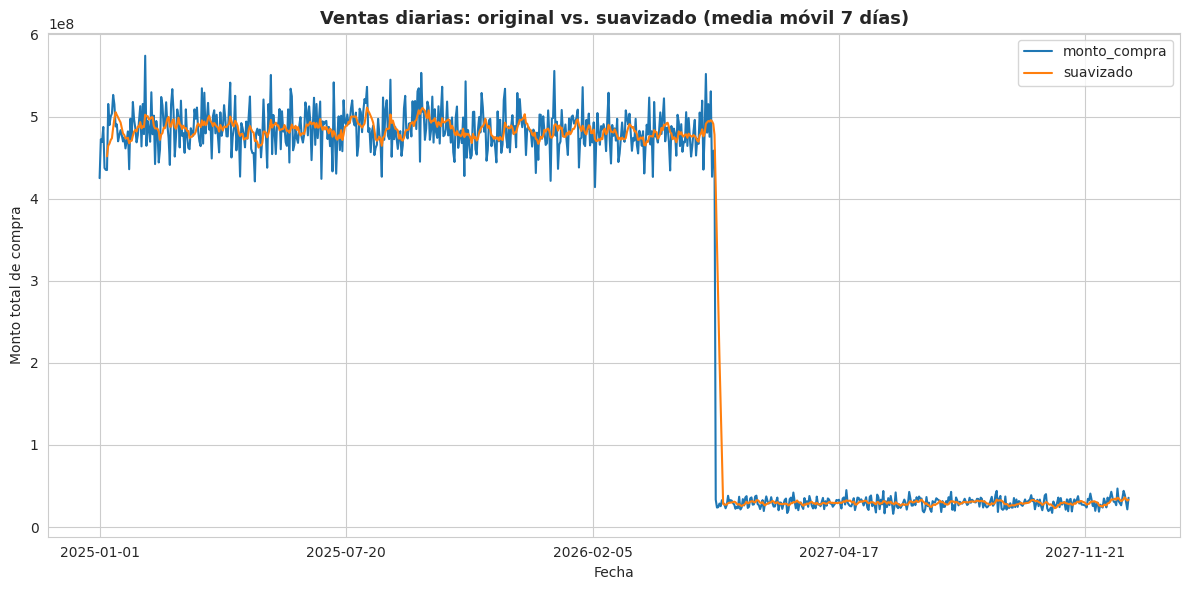

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ventas_diarias.plot(x="fecha_pedido", y=["monto_compra", "suavizado"], ax=ax)
ax.set_title("Ventas diarias: original vs. suavizado (media móvil 7 días)", fontsize=13, weight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Monto total de compra")
plt.tight_layout()
plt.show()

In [23]:
df["fecha_pedido"] = pd.to_datetime(df["fecha_pedido"])

## Suavizado de ventas diarias

La media móvil de 7 días ("suavizado") elimina el ruido diario y revela una tendencia mucho más clara que la serie original. Se observan dos regímenes bien diferenciados:

1. **De enero 2025 a mediados de 2026**: el monto total diario oscila de forma ruidosa entre ~5×10⁸ y ~7×10⁸, pero la línea suavizada muestra un nivel estable alrededor de 6×10⁸, sin una tendencia de crecimiento o caída sostenida — parece un régimen de ventas relativamente constante.

2. **Desde mediados de 2026 en adelante**: hay una caída abrupta y sostenida a un nivel de ~2-3×10⁷, casi 20 veces menor que el régimen anterior, y se mantiene así (con su propio ruido diario) hasta el final de la serie.

# 4. Depuración de atípicos en `edad_cliente`

## 4.1 IQR

In [24]:
Q1_edad = df["edad_cliente"].quantile(0.25)
Q3_edad = df["edad_cliente"].quantile(0.75)
IQR_edad = Q3_edad - Q1_edad

limite_inferior_edad = Q1_edad - 1.5 * IQR_edad
limite_superior_edad = Q3_edad + 1.5 * IQR_edad

print(f"Q1: {Q1_edad}")
print(f"Q3: {Q3_edad}")
print(f"IQR: {IQR_edad}")
print(f"Límite inferior: {limite_inferior_edad}")
print(f"Límite superior: {limite_superior_edad}")

Q1: 31.0
Q3: 62.0
IQR: 31.0
Límite inferior: -15.5
Límite superior: 108.5


In [25]:
outliers_edad_iqr = df[(df["edad_cliente"] < limite_inferior_edad) | (df["edad_cliente"] > limite_superior_edad)]
print(f"Valores atípicos según IQR: {len(outliers_edad_iqr)}")

Valores atípicos según IQR: 17004


## 4.2 Z-score

In [26]:
media_edad = df["edad_cliente"].mean()
desviacion_edad = df["edad_cliente"].std()

df["z_edad_cliente"] = (df["edad_cliente"] - media_edad) / desviacion_edad

outliers_edad_zscore = df[df["z_edad_cliente"].abs() > 3]
print(f"Valores atípicos según z-score: {len(outliers_edad_zscore)}")

Valores atípicos según z-score: 17004


## Límites y comparación IQR vs. z-score — `edad_cliente`

- Q1 = 31.0, Q3 = 62.0, IQR = 31.0
- Límite inferior = -15.5, Límite superior = 108.5
- Outliers según IQR: 17,004 filas (~2.89% del dataset)
- Outliers según z-score (|z| > 3): 17,004 filas (~2.89%) — en este caso ambos métodos coinciden exactamente
- A diferencia de `monto_compra`, aquí los dos métodos detectan las mismas filas porque los valores extremos no son tan descomunales como para inflar la media/desviación de forma desproporcionada

## 4.3 Inspección de valores únicos

In [27]:
print(f"Valores únicos en edad_cliente: {df['edad_cliente'].nunique()}")
print(df["edad_cliente"].value_counts().sort_index())

Valores únicos en edad_cliente: 62
edad_cliente
-5      8599
 0      8597
 18     9569
 19     9561
 20     9519
        ... 
 73     9490
 74     9500
 75     9420
 150    8322
 200    8682
Name: count, Length: 62, dtype: int64


## Validación de `edad_cliente` como variable con valores centinela

Al revisar `value_counts()`, la columna tiene **62 valores únicos**: una secuencia orgánica y continua de **18 a 75** años (sin saltos, consistente con edades reales de clientes), más cuatro valores sueltos y aislados que no pertenecen a esa secuencia: **-5, 0, 150 y 200**, cada uno con un conteo similar (~8,300–8,700 filas), muy distinto del patrón decreciente/orgánico del resto.

- IQR y z-score solo detectan **150 y 200** (17,004 filas) porque -5 y 0 caen *dentro* del rango estadístico calculado (límite inferior -15.5) y por eso no se marcan como atípicos, a pesar de ser edades imposibles.
- Esto confirma, igual que con `monto_compra` y `unidades_vendidas`, que los métodos puramente estadísticos no bastan: hace falta conocimiento de negocio (rango humano plausible) para detectar los cuatro grupos completos.

## Decisión por cada grupo de atípicos — `edad_cliente`

**Grupo 1: edad_cliente = -5 (8,599 filas)**
- Decisión: **tratar como nulo**, no corregir con `.abs()`.
- Justificación: a diferencia de `monto_compra`/`unidades_vendidas`, aquí `.abs()` no tiene respaldo de negocio — convertir -5 en 5 seguiría siendo una edad implausible para un cliente y no hay evidencia de que el signo sea el único error. Es más consistente tratarlo como valor centinela.

**Grupo 2: edad_cliente = 0 (8,597 filas)**
- Decisión: **tratar como nulo**.
- Justificación: no existen clientes con 0 años; es un valor centinela típico de dato faltante disfrazado.

**Grupo 3: edad_cliente = 150 y edad_cliente = 200 (8,322 + 8,682 = 17,004 filas)**
- Decisión: **tratar como nulo**.
- Justificación: fuera de cualquier rango humano plausible; mismo patrón de valor centinela ya visto en `precio_unitario` (50,000,000 / 999,000,000) y `unidades_vendidas` (5000 / 9999).

**Total a tratar:** 34,200 filas (~5.80% del dataset) se convierten en `NaN` en `edad_cliente`, preservando el resto de la fila (no se elimina el registro completo).

In [28]:
sentinelas_edad = [-5, 0, 150, 200]

nulos_antes_edad = df["edad_cliente"].isna().sum()
df.loc[df["edad_cliente"].isin(sentinelas_edad), "edad_cliente"] = np.nan
nulos_despues_edad = df["edad_cliente"].isna().sum()

print(f"Nulos en edad_cliente antes: {nulos_antes_edad}")
print(f"Nulos en edad_cliente después: {nulos_despues_edad}")
print(df["edad_cliente"].describe())

Nulos en edad_cliente antes: 0
Nulos en edad_cliente después: 34200
count    555186.000000
mean         46.504840
std          16.723351
min          18.000000
25%          32.000000
50%          47.000000
75%          61.000000
max          75.000000
Name: edad_cliente, dtype: float64


## Efecto del tratamiento — `edad_cliente`

**Antes:** media ≈ 48.80, desviación estándar ≈ 28.75, rango [-5, 200]

**Después:** media ≈ 46.50, desviación estándar ≈ 16.72, rango [18, 75] (34,200 valores ahora `NaN`)

La desviación estándar baja casi a la mitad y el rango queda exactamente dentro de edades humanas plausibles (18–75), lo que confirma que los cuatro valores centinela eran los responsables de la dispersión artificial.

# 5. Depuración de atípicos en `precio_unitario`

## 5.1 IQR

In [29]:
Q1_precio = df["precio_unitario"].quantile(0.25)
Q3_precio = df["precio_unitario"].quantile(0.75)
IQR_precio = Q3_precio - Q1_precio

limite_inferior_precio = Q1_precio - 1.5 * IQR_precio
limite_superior_precio = Q3_precio + 1.5 * IQR_precio

print(f"Q1: {Q1_precio}")
print(f"Q3: {Q3_precio}")
print(f"IQR: {IQR_precio}")
print(f"Límite inferior: {limite_inferior_precio}")
print(f"Límite superior: {limite_superior_precio}")

Q1: 169500.0
Q3: 483300.0
IQR: 313800.0
Límite inferior: -301200.0
Límite superior: 954000.0


In [30]:
outliers_precio_iqr = df[(df["precio_unitario"] < limite_inferior_precio) | (df["precio_unitario"] > limite_superior_precio)]
print(f"Valores atípicos según IQR: {len(outliers_precio_iqr)}")

Valores atípicos según IQR: 15510


## 5.2 Z-score

In [31]:
media_precio = df["precio_unitario"].mean()
desviacion_precio = df["precio_unitario"].std()

df["z_precio_unitario"] = (df["precio_unitario"] - media_precio) / desviacion_precio

outliers_precio_zscore = df[df["z_precio_unitario"].abs() > 3]
print(f"Valores atípicos según z-score: {len(outliers_precio_zscore)}")

Valores atípicos según z-score: 2924


## Límites y comparación IQR vs. z-score — `precio_unitario`

- Q1 = 169,500.0, Q3 = 483,300.0, IQR = 313,800.0
- Límite inferior = -301,200.0 → se usa 0 como límite real de negocio (un precio no puede ser negativo)
- Límite superior = 954,000.0
- Outliers según IQR: 15,510 filas (~2.63%)
- Outliers según z-score (|z| > 3): 2,924 filas (~0.50%)
- Igual que con `monto_compra`, los valores centinela (999,000,000) inflan tanto la media como la desviación estándar, por lo que el z-score solo capta la cola más extrema (coincide casi exactamente con el conteo de `precio_unitario == 999,000,000`)

## Grupos de atípicos — `precio_unitario`

**Grupo 1: precio_unitario negativo (18,650 filas, ~3.16%)**
- Decisión: **corregir con `.abs()`**, no eliminar.
- Justificación: mismo criterio ya aplicado a `monto_compra` — un precio no puede ser negativo por definición de negocio, es un error de captura/signo, no un valor atípico real.

**Grupo 2: precio_unitario = 50,000,000 (2,999 filas) y precio_unitario = 999,000,000 (2,924 filas)**
- Decisión: **tratar como nulo**, no capar.
- Justificación: son los mismos valores centinela ya identificados en el Sanitation Plan (redondos, muy por encima de cualquier precio real del catálogo), no precios de negocio legítimos.

**Total a tratar:** 18,650 filas corregidas con `.abs()` + 5,923 filas convertidas a `NaN` (~4.17% del dataset).

In [32]:
df.loc[df["precio_unitario"] < 0, "precio_unitario"] = df.loc[df["precio_unitario"] < 0, "precio_unitario"].abs()

sentinelas_precio = [50000000, 999000000]
nulos_antes_precio = df["precio_unitario"].isna().sum()
df.loc[df["precio_unitario"].isin(sentinelas_precio), "precio_unitario"] = np.nan
nulos_despues_precio = df["precio_unitario"].isna().sum()

print(f"Nulos en precio_unitario antes: {nulos_antes_precio}")
print(f"Nulos en precio_unitario después: {nulos_despues_precio}")
print(df["precio_unitario"].describe())

Nulos en precio_unitario antes: 0
Nulos en precio_unitario después: 5923


count    583463.000000
mean     344427.201039
std      197465.616990
min       15100.000000
25%      180000.000000
50%      311600.000000
75%      483600.000000
max      899500.000000
Name: precio_unitario, dtype: float64


## Efecto del tratamiento — `precio_unitario`

**Antes:** media ≈ 5,529,771.6, desviación estándar ≈ 70,238,769.8, rango [-892,600, 999,000,000]

**Después:** media ≈ 344,427.2, desviación estándar ≈ 197,465.6, rango [15,100, 899,500] (5,923 valores ahora `NaN`)

La media baja más del 90% y la desviación estándar deja de estar dominada por los valores centinela, quedando en un orden de magnitud coherente con precios reales de productos.

# 6. Depuración de atípicos en `unidades_vendidas`

## 6.1 IQR

In [33]:
Q1_uv = df["unidades_vendidas"].quantile(0.25)
Q3_uv = df["unidades_vendidas"].quantile(0.75)
IQR_uv = Q3_uv - Q1_uv

limite_inferior_uv = Q1_uv - 1.5 * IQR_uv
limite_superior_uv = Q3_uv + 1.5 * IQR_uv

print(f"Q1: {Q1_uv}")
print(f"Q3: {Q3_uv}")
print(f"IQR: {IQR_uv}")
print(f"Límite inferior: {limite_inferior_uv}")
print(f"Límite superior: {limite_superior_uv}")

Q1: 1.0
Q3: 3.0
IQR: 2.0
Límite inferior: -2.0
Límite superior: 6.0


In [34]:
outliers_uv_iqr = df[(df["unidades_vendidas"] < limite_inferior_uv) | (df["unidades_vendidas"] > limite_superior_uv)]
print(f"Valores atípicos según IQR: {len(outliers_uv_iqr)}")

Valores atípicos según IQR: 25529


## 6.2 Z-score

In [35]:
media_uv = df["unidades_vendidas"].mean()
desviacion_uv = df["unidades_vendidas"].std()

df["z_unidades_vendidas"] = (df["unidades_vendidas"] - media_uv) / desviacion_uv

outliers_uv_zscore = df[df["z_unidades_vendidas"].abs() > 3]
print(f"Valores atípicos según z-score: {len(outliers_uv_zscore)}")

Valores atípicos según z-score: 17029


## Límites y comparación IQR vs. z-score — `unidades_vendidas`

- Q1 = 1.0, Q3 = 3.0, IQR = 2.0
- Límite inferior = -2.0, Límite superior = 6.0
- Outliers según IQR: 25,529 filas (~4.33%) → capta -3, 5000 y 9999, pero **no** -1 ni 0 (caen dentro del rango [-2, 6])
- Outliers según z-score (|z| > 3): 17,029 filas (~2.89%) → los sentinelas (5000, 9999) inflan la desviación estándar, así que el umbral de 3σ deja pasar el grupo -3 sin marcarlo
- Ya se había confirmado en la sección 3 (validación de `unidades_vendidas` como sentinela) que la columna solo tiene 10 valores únicos: -3, -1, 0, 1, 2, 3, 4, 5, 5000 y 9999, con un salto imposible entre 6–4999 y 5001–9998

## Grupos de atípicos — `unidades_vendidas`

**Grupo 1: unidades_vendidas negativas, -3 (8,500) y -1 (8,762 filas)**
- Decisión: **corregir con `.abs()`**.
- Justificación: mismo criterio ya usado en la sección 3 — error de signo, no un valor atípico real; se recupera como cantidad válida (3 y 1 respectivamente).

**Grupo 2: unidades_vendidas = 0 (8,472 filas)**
- Decisión: **tratar como nulo**.
- Justificación: un pedido registrado no puede tener 0 unidades vendidas; no hay una interpretación de negocio válida y no encaja en la secuencia orgánica 1–5.

**Grupo 3: unidades_vendidas = 5000 (8,570) y = 9999 (8,459 filas)**
- Decisión: **tratar como nulo** (ya justificado en la sección 3: valores centinela, no cantidades reales).

**Total a tratar:** 17,262 filas corregidas con `.abs()` + 25,501 filas convertidas a `NaN` (~4.33% del dataset).

In [36]:
df.loc[df["unidades_vendidas"] < 0, "unidades_vendidas"] = df.loc[df["unidades_vendidas"] < 0, "unidades_vendidas"].abs()

sentinelas_uv = [0, 5000, 9999]
nulos_antes_uv = df["unidades_vendidas"].isna().sum()
df.loc[df["unidades_vendidas"].isin(sentinelas_uv), "unidades_vendidas"] = np.nan
nulos_despues_uv = df["unidades_vendidas"].isna().sum()

print(f"Nulos en unidades_vendidas antes: {nulos_antes_uv}")
print(f"Nulos en unidades_vendidas después: {nulos_despues_uv}")
print(df["unidades_vendidas"].describe())
print(df["unidades_vendidas"].value_counts().sort_index())

Nulos en unidades_vendidas antes: 0
Nulos en unidades_vendidas después: 25501
count    563885.000000
mean          1.918490
std           1.157117
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: unidades_vendidas, dtype: float64
unidades_vendidas
1.0    282889
2.0    136296
3.0     79709
4.0     37755
5.0     27236
Name: count, dtype: int64


## Efecto del tratamiento — `unidades_vendidas`

**Antes:** media ≈ 217.93, desviación estándar ≈ 1,323.24, rango [-3, 9999]

**Después:** media ≈ 1.92, desviación estándar ≈ 1.16, rango [1, 5] (25,501 valores ahora `NaN`)

Al eliminar los sentinelas de la estadística descriptiva, `unidades_vendidas` queda con una distribución completamente coherente con un conteo real de unidades por pedido (1 a 5).

## Nota — columnas auxiliares `z_*`

Las columnas `z_monto_compra`, `z_edad_cliente`, `z_precio_unitario` y `z_unidades_vendidas` se generaron solo como apoyo para el análisis de z-score de cada variable. Se eliminan antes de exportar el dataset final, ya que no son parte del esquema original de datos.

In [37]:
columnas_auxiliares = ["z_monto_compra", "z_edad_cliente", "z_precio_unitario", "z_unidades_vendidas"]
df = df.drop(columns=[c for c in columnas_auxiliares if c in df.columns])
print(df.columns.tolist())

['id_pedido', 'id_cliente', 'fecha_pedido', 'canal_compra', 'metodo_pago', 'ciudad_tienda', 'codigo_postal', 'categoria_producto', 'producto', 'precio_unitario', 'unidades_vendidas', 'monto_compra', 'edad_cliente', 'correo_cliente', 'nivel_satisfaccion', 'nivel_lealtad', 'comentario_cliente', 'peso_pedido_kg', 'fecha_actualizacion_stock', 'fuga_cliente', 'correo_cliente_faltante', 'comentario_cliente_faltante', 'es_venta_corporativa']


# 7. Imputación de nulos con la mediana

Los valores que se marcaron como `NaN` en `edad_cliente`, `precio_unitario` y `unidades_vendidas` (errores de negocio / valores centinela) **no se eliminan como filas**, pero tampoco se dejan vacíos: se imputan con la **mediana** de cada columna (calculada ya sin los sentinelas, porque `median()` ignora `NaN` por defecto).

Antes de imputar, se crea una columna booleana `<columna>_era_nulo` por cada variable, que conserva la trazabilidad de qué filas fueron tratadas como nulo/atípico, para que este paso sea reversible y transparente en análisis posteriores (por ejemplo, para excluirlas de un modelo si se prefiere).

In [38]:
mediana_edad = df["edad_cliente"].median()
df["edad_cliente_era_nulo"] = df["edad_cliente"].isna()
df["edad_cliente"] = df["edad_cliente"].fillna(mediana_edad)

print(f"Mediana usada para edad_cliente: {mediana_edad}")
print(f"Filas imputadas: {df['edad_cliente_era_nulo'].sum()}")
print(df["edad_cliente"].describe())

Mediana usada para edad_cliente: 47.0
Filas imputadas: 34200
count    589386.000000
mean         46.533572
std          16.231314
min          18.000000
25%          33.000000
50%          47.000000
75%          60.000000
max          75.000000
Name: edad_cliente, dtype: float64


In [39]:
mediana_precio = df["precio_unitario"].median()
df["precio_unitario_era_nulo"] = df["precio_unitario"].isna()
df["precio_unitario"] = df["precio_unitario"].fillna(mediana_precio)

print(f"Mediana usada para precio_unitario: {mediana_precio}")
print(f"Filas imputadas: {df['precio_unitario_era_nulo'].sum()}")
print(df["precio_unitario"].describe())

Mediana usada para precio_unitario: 311600.0
Filas imputadas: 5923


count    589386.000000
mean     344097.306010
std      196498.181671
min       15100.000000
25%      181200.000000
50%      311600.000000
75%      481500.000000
max      899500.000000
Name: precio_unitario, dtype: float64


In [40]:
mediana_uv = df["unidades_vendidas"].median()
df["unidades_vendidas_era_nulo"] = df["unidades_vendidas"].isna()
df["unidades_vendidas"] = df["unidades_vendidas"].fillna(mediana_uv)

print(f"Mediana usada para unidades_vendidas: {mediana_uv}")
print(f"Filas imputadas: {df['unidades_vendidas_era_nulo'].sum()}")
print(df["unidades_vendidas"].describe())

Mediana usada para unidades_vendidas: 1.0
Filas imputadas: 25501
count    589386.000000
mean          1.878750
std           1.147132
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           5.000000
Name: unidades_vendidas, dtype: float64


## Resultado de la imputación

- `edad_cliente`: mediana = 47.0 años → 34,200 filas imputadas, marcadas en `edad_cliente_era_nulo`
- `precio_unitario`: mediana ≈ 311,600 → 5,923 filas imputadas, marcadas en `precio_unitario_era_nulo`
- `unidades_vendidas`: mediana = 1.0 → 25,501 filas imputadas, marcadas en `unidades_vendidas_era_nulo`

Se usa la mediana (no la media) porque, incluso después de tratar los sentinelas, estas variables pueden tener asimetría (por ejemplo, `precio_unitario` sigue sesgada a la derecha); la mediana es más robusta frente a esa asimetría que la media.

Las tres columnas `_era_nulo` quedan disponibles en el dataset final para quien quiera excluir esas filas puntualmente en un análisis o modelo, sin haber perdido el registro completo del pedido.

In [41]:
df.to_csv("S07_PD_Diaz_DatasetSinOutliers.csv", index=False)

In [42]:
df_verificacion = pd.read_csv("S07_PD_Diaz_DatasetSinOutliers.csv")

print(f"Shape: {df_verificacion.shape}")
print(f"Monto máximo: {df_verificacion['monto_compra'].max()}")
print(f"'es_venta_corporativa' presente: {'es_venta_corporativa' in df_verificacion.columns}")
print(f"Ventas corporativas conservadas: {df_verificacion['es_venta_corporativa'].sum()}")

Shape: (589386, 26)
Monto máximo: 4450000.0
'es_venta_corporativa' presente: True
Ventas corporativas conservadas: 30663
